# Proyecto Final Big Data Tools

## Análisis SIEVCAC con metodología CRISP-DM

Este notebook ejecuta el flujo técnico completo: ETL, EDA, estadística descriptiva e inferencial, procesamiento geoespacial, modelado supervisado y despliegue técnico.

## 0. Configuración del proyecto

La lógica principal está en `src/bdtools`. El notebook funciona como punto de ejecución y presentación de resultados.

In [1]:
from pathlib import Path
import sys
import warnings

import pandas as pd

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "src" / "bdtools").exists():
            return path
    raise RuntimeError("No se encontró la carpeta src/bdtools.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(PROJECT_ROOT)

C:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto2\ProyectoFinalBDTools_CRISPDM


In [2]:
from bdtools import __version__
from bdtools import config as cfg

print("bdtools", __version__)
print(cfg.__file__)
print(cfg.RAW_DIR)

bdtools 1.0.0
C:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto2\ProyectoFinalBDTools_CRISPDM\src\bdtools\config.py
C:\Users\HOME\Documents\Enfasis Big Data Tools\Proyecto2\ProyectoFinalBDTools_CRISPDM\data\raw


## 1. Comprensión del negocio

El análisis se centra en casos de reclutamiento y utilización de niños, niñas y adolescentes en el conflicto armado colombiano. El objetivo técnico es transformar el dataset SIEVCAC en una solución reproducible que permita describir patrones temporales, territoriales y categóricos, evaluar asociaciones estadísticas y construir modelos supervisados para identificar casos de alto impacto.

La variable objetivo `alto_impacto` se define a partir del número de víctimas del caso. Se marca como 1 cuando el caso registra más de una víctima y como 0 en los demás casos. Esta definición permite plantear el problema como clasificación binaria.

## 2. Comprensión de los datos

Se carga el archivo original desde `data/raw`, se revisa la calidad de las variables y se exporta una tabla de diagnóstico.

In [3]:
from bdtools.io import read_raw_data

raw_df = read_raw_data()
raw_df.shape

(17201, 27)

In [4]:
raw_df.head()

,ID Caso,ID Caso Relacionado,Año,Mes,Día,Código DANE de Municipio,Municipio,Departamento,Región,Modalidad,...,Extorsión,Lesionados Civiles,Pillaje,Tortura,Violencia Basada en Género,Otro Hecho Simultáneo,Total de Víctimas del Caso,Forma de Vinculación,Tipo de Vinculación,latitud-longitud
0,152.888,NaN,2.004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,SIN INFORMACIÓN,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893)
1,207.556,NaN,2.001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-74.82807326 5.837681474)
2,209.268,NaN,0.000,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-76.31426328 6.992243782)
3,225.057,NaN,1.988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-73.53900334 6.894292346)
4,228.661,NaN,1.998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,...,0,0,0,0,NaN,OCULTAMIENTO DE CADÁVER,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-75.90432634 5.416268487)


In [5]:
raw_df.dtypes.rename("tipo").to_frame().head(20)

,tipo
ID Caso,float64
ID Caso Relacionado,str
Año,float64
Mes,int64
Día,int64
Código DANE de Municipio,str
Municipio,str
Departamento,str
Región,str
Modalidad,str


## 3. Preparación de los datos

La preparación incluye normalización de nombres de columnas, depuración de columnas con exceso de nulos, tratamiento de fechas inválidas, estandarización de texto, extracción de coordenadas y creación de variables derivadas.

In [6]:
from bdtools.io import run_etl

# Si el archivo tiene otro nombre, basta con dejarlo dentro de data/raw.
df, calidad_datos = run_etl()

df.shape

(17201, 32)

In [7]:
df.head()

,id_caso,anio,mes,dia,codigo_dane_de_municipio,municipio,departamento,region,modalidad,presunto_responsable,...,tipo_vinculacion,latitud_longitud,anio_valido,mes_valido,dia_valido,decada,latitud,longitud,alto_impacto,total_hechos
0,152.888,2.004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,GRUPO PARAMILITAR,...,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893),<NA>,4,<NA>,SIN INFORMACION,6.219481,-74.571689,0,1
1,207.556,2.001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,GRUPO PARAMILITAR,...,RECLUTAMIENTO,POINT (-74.82807326 5.837681474),<NA>,4,25,SIN INFORMACION,5.837681,-74.828073,0,1
2,209.268,0.000,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,GUERRILLA,...,RECLUTAMIENTO,POINT (-76.31426328 6.992243782),<NA>,<NA>,<NA>,SIN INFORMACION,6.992244,-76.314263,0,0
3,225.057,1.988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,GUERRILLA,...,RECLUTAMIENTO,POINT (-73.53900334 6.894292346),<NA>,<NA>,<NA>,SIN INFORMACION,6.894292,-73.539003,0,0
4,228.661,1.998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,GUERRILLA,...,RECLUTAMIENTO,POINT (-75.90432634 5.416268487),<NA>,2,15,SIN INFORMACION,5.416268,-75.904326,0,0


In [8]:
calidad_datos.head(15)

,variable,tipo_limpio,nulos_raw_pct,nulos_limpio_pct,valores_unicos_limpio
4,anio_valido,Int64,NaN,100.00,0
13,dia_valido,Int64,NaN,69.57,31
23,mes_valido,Int64,NaN,67.31,12
0,abandono_o_despojo_forzado_de_tierras,int64,0.0,0.00,2
1,alto_impacto,int64,NaN,0.00,2
2,amenaza_o_intimidacion,int64,0.0,0.00,2
3,anio,float64,0.0,0.00,51
5,ataque_contra_mision_medica,int64,0.0,0.00,1
6,codigo_dane_de_municipio,str,0.0,0.00,833
7,confinamiento_o_restriccion_a_la_movilidad,int64,0.0,0.00,2


## 4. EDA y estadística descriptiva

Se generan tablas de frecuencia, resumen general y las figuras principales del análisis exploratorio.

In [6]:
from bdtools.eda import build_eda_reports
from bdtools.statistics import build_statistics_reports
from bdtools.geo import build_geospatial_outputs
from bdtools.modeling import train_and_evaluate_models

eda_outputs = build_eda_reports(df, calidad_datos)
stats_outputs = build_statistics_reports(df)
gdf = build_geospatial_outputs(df)
model_outputs = train_and_evaluate_models(df)

eda_outputs["resumen_general"]

c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one 

,indicador,valor
0,registros,17201.0
1,variables,32.0
2,duplicados,0.0
3,victimas_total,18182.0
4,anio_valido_unicos,0.0
5,departamento_unicos,35.0
6,region_unicos,76.0
7,modalidad_unicos,5.0
8,presunto_responsable_unicos,11.0


In [7]:
stats_outputs["estadistica_descriptiva"]

,indicador,valor
0,casos,17201.0000
1,variables,32.0000
2,victimas_total,18182.0000
3,victimas_media,1.0570
4,victimas_mediana,1.0000
5,victimas_max,150.0000
6,alto_impacto_proporcion,0.0229
7,alto_impacto_ic95_inf,0.0207
8,alto_impacto_ic95_sup,0.0251


In [8]:
eda_outputs.get("frecuencia_departamento").head(10)

,departamento,casos,porcentaje
0,ANTIOQUIA,2749,15.98
1,SIN INFORMACION,2413,14.03
2,META,1513,8.80
3,CAQUETA,1263,7.34
4,CAUCA,776,4.51
5,TOLIMA,741,4.31
6,NARIÑO,629,3.66
7,PUTUMAYO,533,3.10
8,CHOCO,498,2.90
9,ARAUCA,488,2.84


In [9]:
eda_outputs.get("frecuencia_modalidad").head(10)

,modalidad,casos,porcentaje
0,DESCONOCIDA,8311,48.32
1,PERSUASIÓN,6818,39.64
2,COACCIÓN,2043,11.88
3,ENGAÑO,26,0.15
4,OTRA ¿CUÁL?,3,0.02


No se encontró: casos_por_anio.png


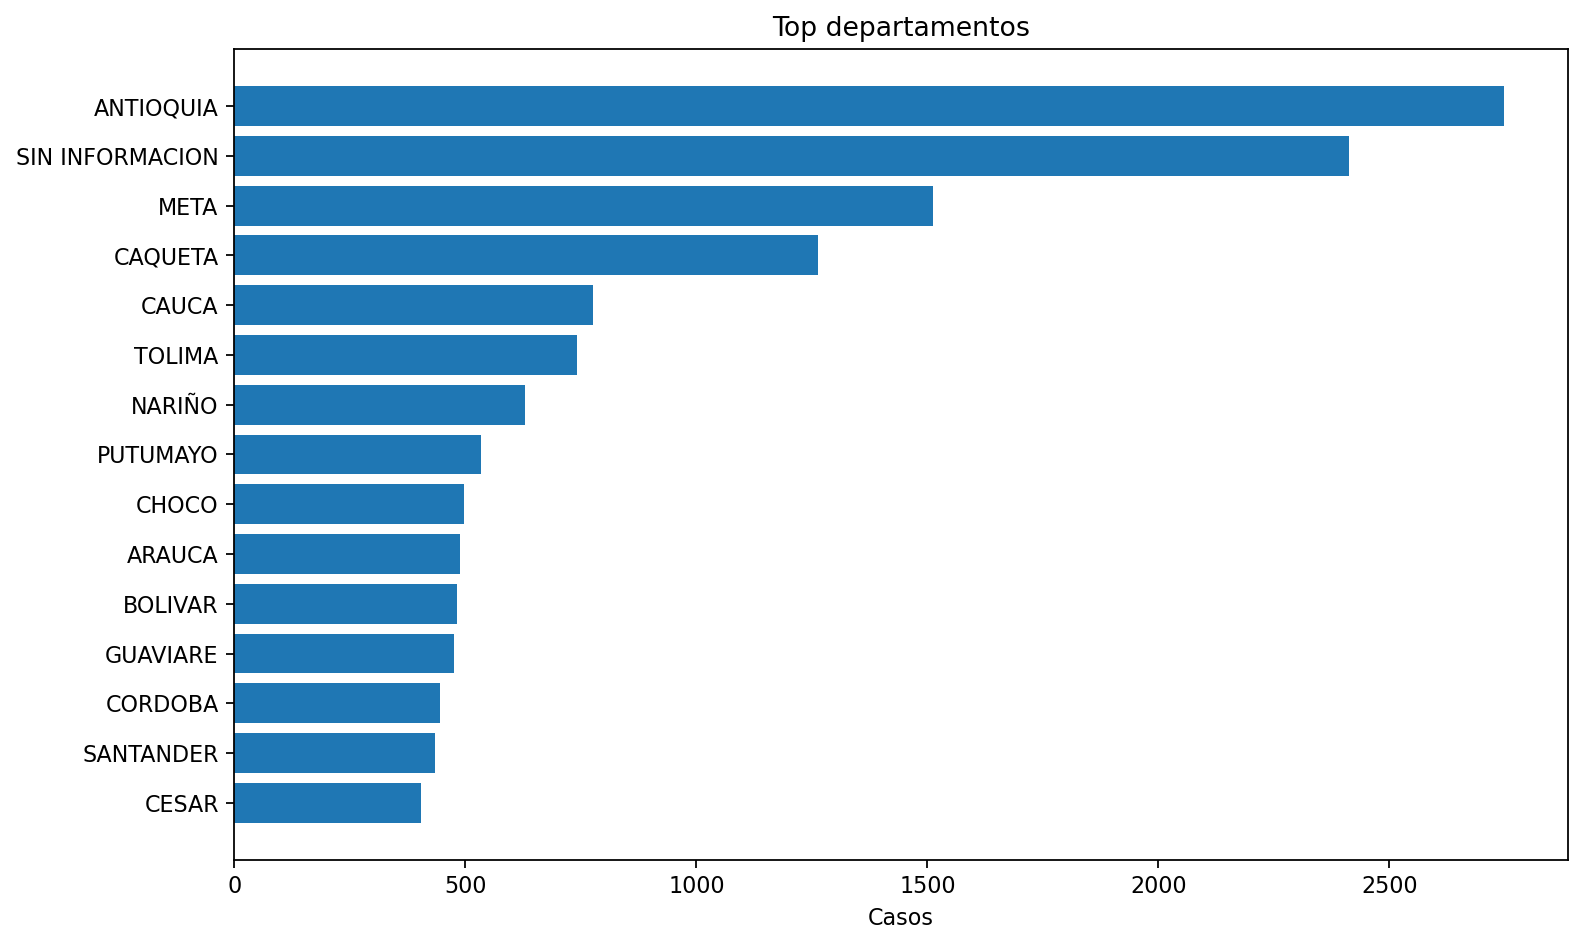

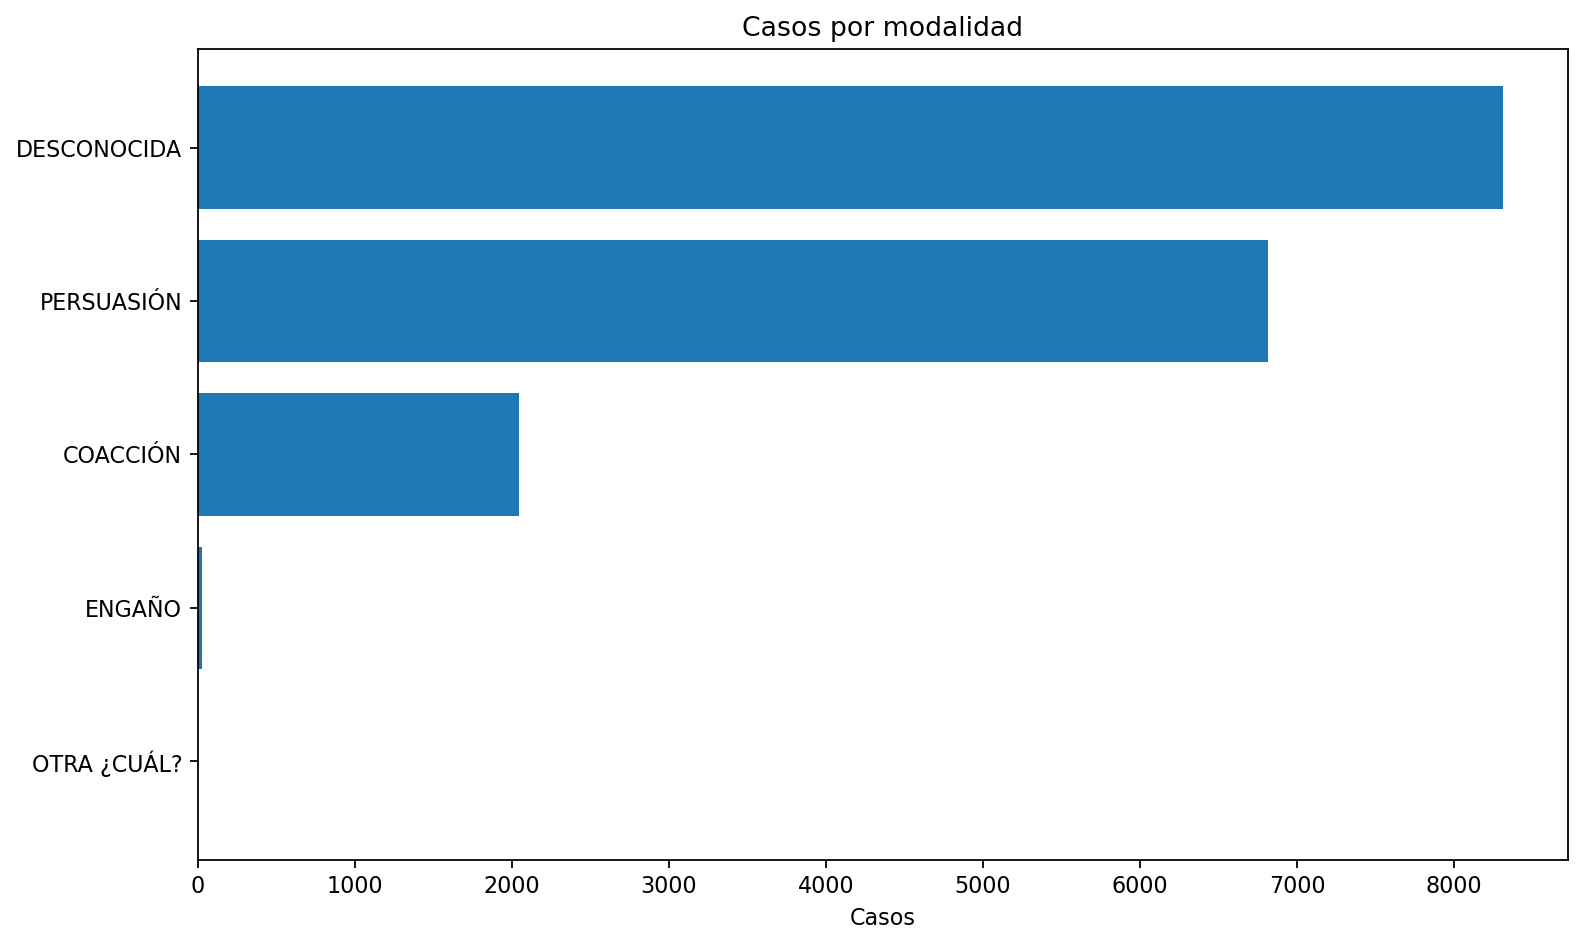

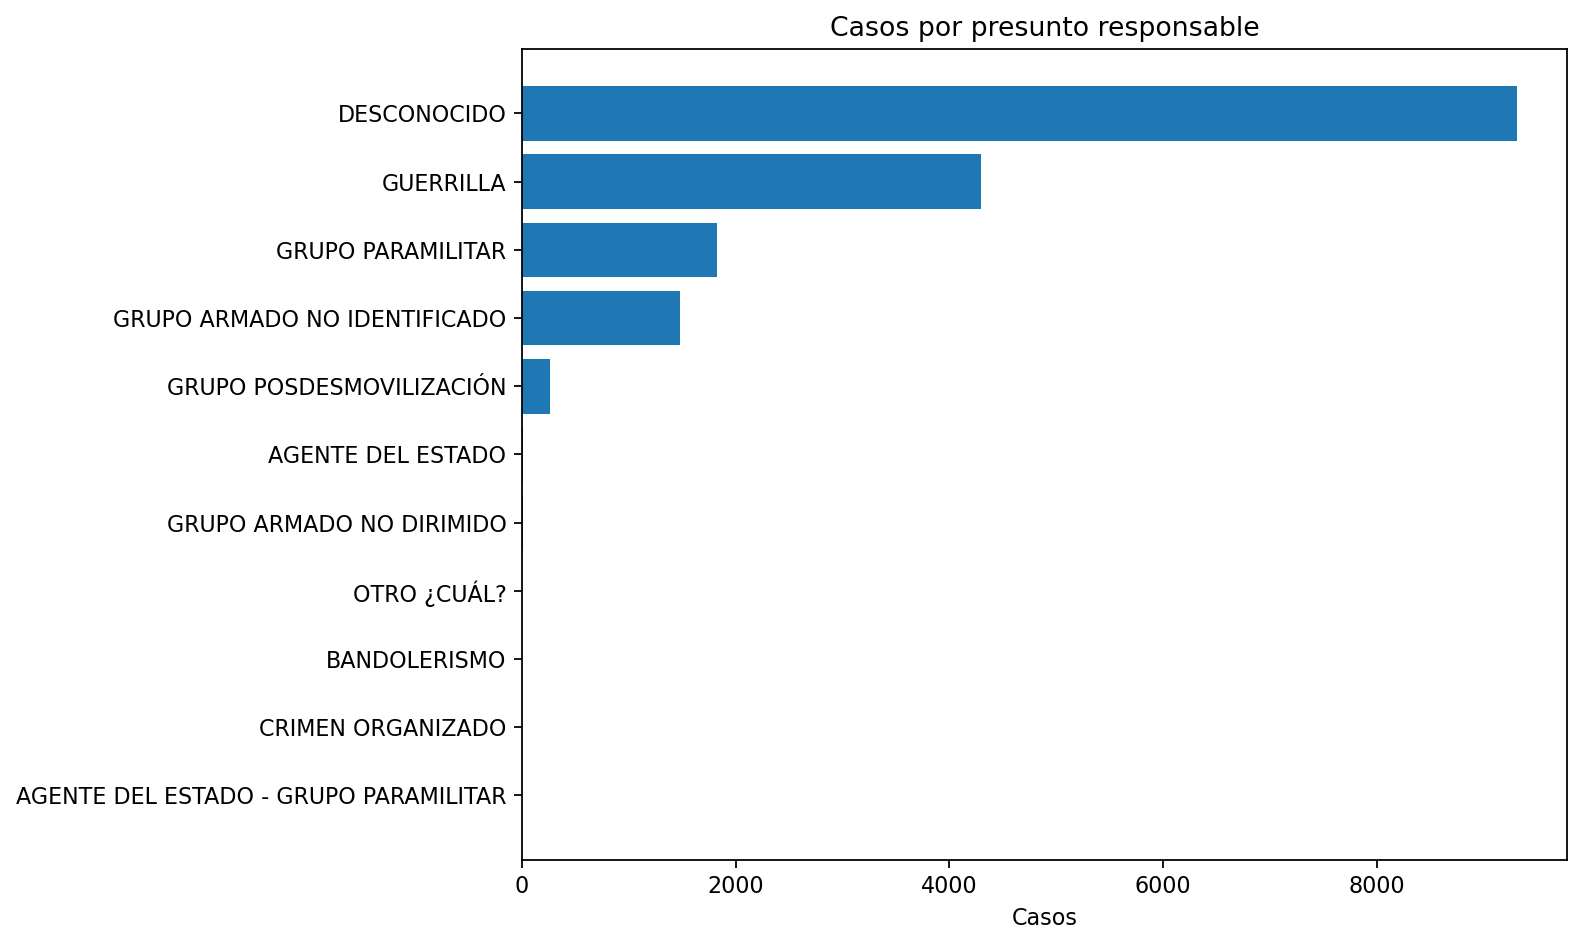

In [15]:
import bdtools.config as cfg
from IPython.display import Image, display

figuras_eda = [
    cfg.FIG_CASOS_ANIO,
    cfg.FIG_TOP_DEPARTAMENTOS,
    cfg.FIG_MODALIDAD,
    cfg.FIG_RESPONSABLE,
]

for fig in figuras_eda:
    if fig.exists():
        display(Image(filename=str(fig)))
    else:
        print(f"No se encontró: {fig.name}")

### Visualizaciones ampliadas para informe

Estas figuras complementan el EDA inicial con mapa de nulos, auditoría de limpieza, frecuencias categóricas, temporalidad, análisis bivariado, outliers e inferencia avanzada.

In [ ]:
from IPython.display import Image, display

figuras_ampliadas = [
    cfg.FIG_MAPA_NULOS,
    cfg.FIG_PORCENTAJE_NULOS,
    cfg.FIG_COLUMNAS_ELIMINADAS_NULOS,
    cfg.FIG_DISTRIBUCION_DECADA,
    cfg.FIG_FRECUENCIAS_CATEGORICAS,
    cfg.FIG_MODALIDAD_FRECUENCIA_PCT,
    cfg.FIG_TIPO_VINCULACION,
    cfg.FIG_FORMA_VINCULACION,
    cfg.FIG_DEPARTAMENTOS,
    cfg.FIG_REGIONES,
    cfg.FIG_DESCRIPTIVE_PANEL,
    cfg.FIG_VICTIMS_DISTRIBUTION,
    cfg.FIG_HECHOS_DISTRIBUTION,
    cfg.FIG_RESPONSABLE_DETAIL,
    cfg.FIG_MODALIDAD_DETAIL,
    cfg.FIG_TEMPORAL_DECADE_MONTH,
    cfg.FIG_CONFLICT_2000_2010,
    cfg.FIG_GEO_RESP_2000_2010,
    cfg.FIG_CORRELACIONES_HECHOS,
    cfg.FIG_RESP_MODALIDAD,
    cfg.FIG_RESP_DEPARTAMENTOS,
    cfg.FIG_VICTIMAS_BIVARIADO,
    cfg.FIG_TEMPORAL_EVOLUCION,
    cfg.FIG_TEMPORAL_ACTOR,
    cfg.FIG_EVOLUCION_HECHOS,
    cfg.FIG_GEO_CASOS_VICTIMAS,
    cfg.FIG_OUTLIERS_VICTIMAS,
    cfg.FIG_OUTLIERS_DEPARTAMENTO,
    cfg.FIG_INFERENTIAL_ADVANCED,
]

for fig in figuras_ampliadas:
    if fig.exists():
        display(Image(filename=str(fig)))
    else:
        print(f"No se encontró: {fig.name}")

## 5. Estadística inferencial

Se aplican pruebas chi-cuadrado para evaluar asociación entre variables categóricas y la variable `alto_impacto`. También se reporta la proporción de casos de alto impacto con intervalo de confianza del 95%.

In [11]:
stats_outputs["pruebas_chi_cuadrado"]

,variable,chi2,p_value,dof,cramers_v,decision
0,departamento,107.3679,0.000000,34,0.0790,asociacion
2,modalidad,228.8260,0.000000,4,0.1153,asociacion
3,presunto_responsable,624.4256,0.000000,10,0.1905,asociacion
4,tipo_vinculacion,182.1583,0.000000,4,0.1029,asociacion
5,forma_vinculacion,10622.9845,0.000000,6,0.7859,asociacion
1,region,149.1148,0.000001,75,0.0931,asociacion


### Estadística inferencial avanzada

Se agregan pruebas no paramétricas y bootstrap para complementar el análisis inferencial del notebook base.

In [ ]:
display(stats_outputs["estadistica_inferencial_avanzada"])
display(stats_outputs["estadistica_inferencial_grupos"].head(15))
display(stats_outputs["spearman_hechos_victimas"].head(15))
display(stats_outputs["bootstrap_ic_victimas"].head(10))

In [12]:
stats_outputs["resumen_numerico"].head(15)

,variable,count,mean,std,min,25%,50%,75%,max
0,id_caso,17201.0,328.343718,82.93368,35.787,306.64,311.342,315.896,878.753
1,anio,17201.0,0.702111,0.956281,0.0,0.0,0.0,2.002,2.024
2,mes,17201.0,1.977385,3.515863,0.0,0.0,0.0,2.0,12.0
3,dia,17201.0,3.650951,7.684946,0.0,0.0,0.0,1.0,31.0
4,abandono_o_despojo_forzado_de_tierras,17201.0,0.001105,0.033218,0.0,0.0,0.0,0.0,1.0
5,amenaza_o_intimidacion,17201.0,0.011685,0.107469,0.0,0.0,0.0,0.0,1.0
6,ataque_contra_mision_medica,17201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,confinamiento_o_restriccion_a_la_movilidad,17201.0,0.000523,0.022869,0.0,0.0,0.0,0.0,1.0
8,desplazamiento_forzado,17201.0,0.005872,0.076404,0.0,0.0,0.0,0.0,1.0
9,extorsion,17201.0,0.000407,0.02017,0.0,0.0,0.0,0.0,1.0


## 6. Procesamiento geoespacial

Se construye un `GeoDataFrame` en EPSG:4326 y se exporta el archivo GeoJSON para uso en herramientas SIG o visualizadores externos.

In [13]:
from bdtools.geo import build_geospatial_outputs

gdf = build_geospatial_outputs(df)
gdf.shape

(17201, 33)

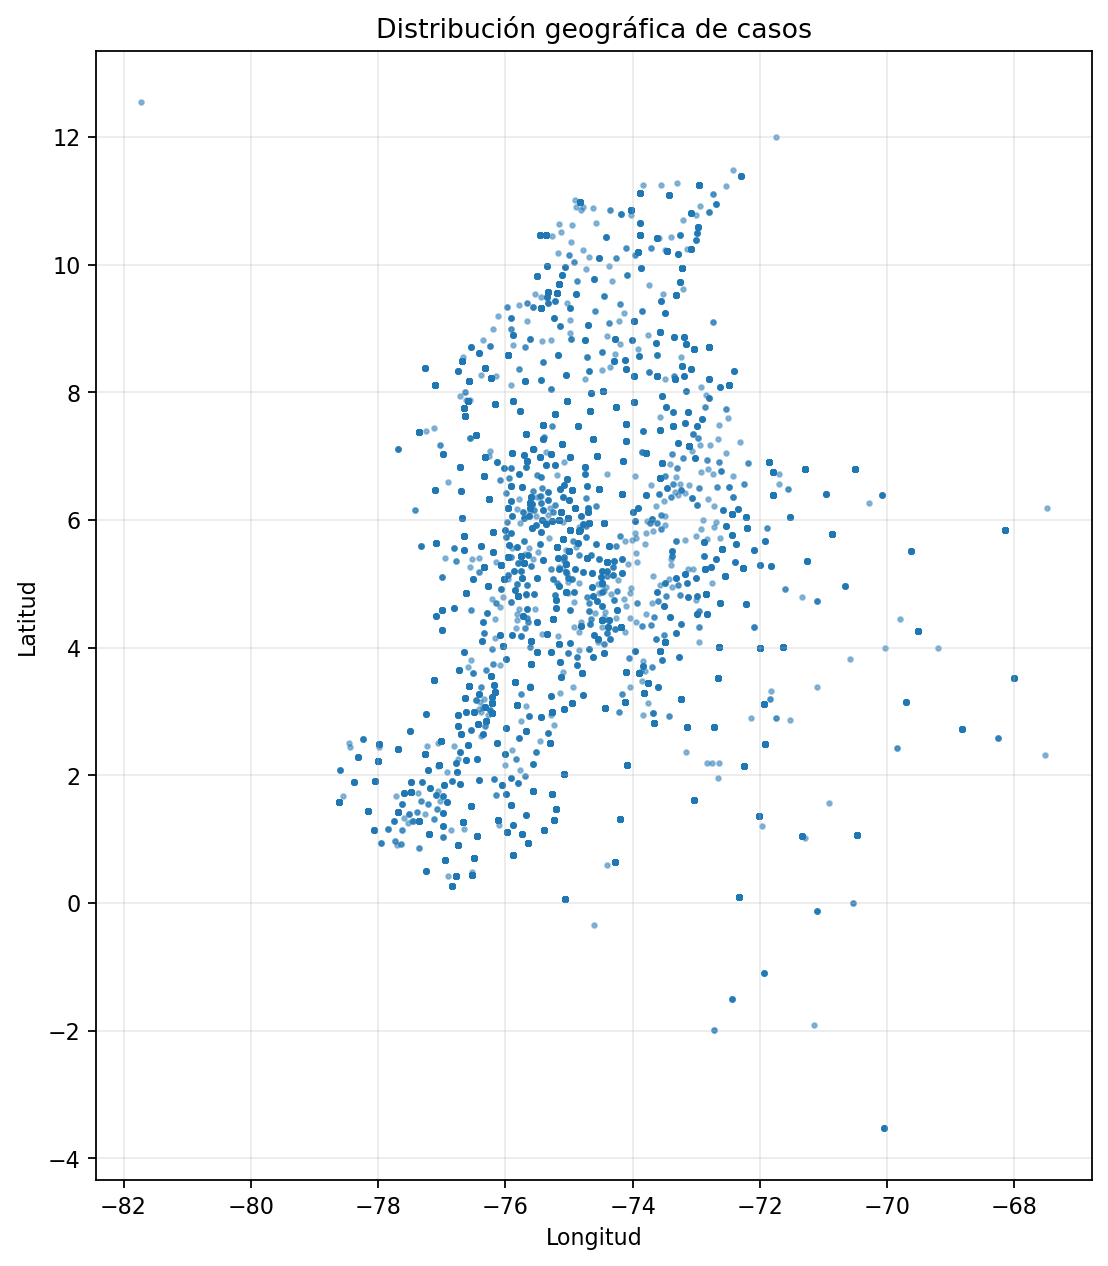

In [16]:
if cfg.FIG_GEO.exists():
    display(Image(filename=str(cfg.FIG_GEO)))

## 7. Modelado: Regresión Logística y Random Forest

El modelado usa únicamente dos clasificadores: Regresión Logística y Random Forest. La variable `total_victimas_caso` no se usa como predictor porque participa en la definición de la variable objetivo.

In [17]:
from bdtools.modeling import train_and_evaluate_models

model_results = train_and_evaluate_models(df)
model_results["metrics"]

c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HOME\anaconda3\envs\proyectofinalbdtools\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['anio_valido']. At least one 

,modelo,accuracy,precision,recall,f1,roc_auc
1,random_forest,0.9785,0.5177,0.9241,0.6636,0.9816
0,logistica,0.9628,0.3756,0.9367,0.5362,0.9852


## 8. Evaluación de modelos

La comparación se realiza con accuracy, precision, recall, F1 y ROC AUC. Las matrices de confusión se exportan como figuras.

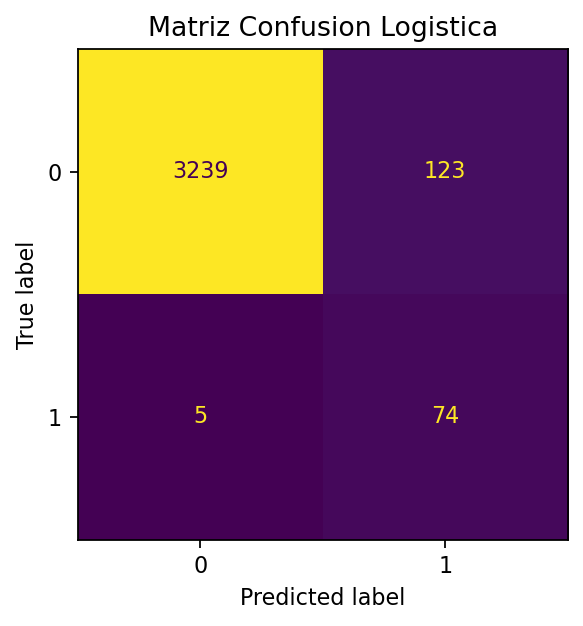

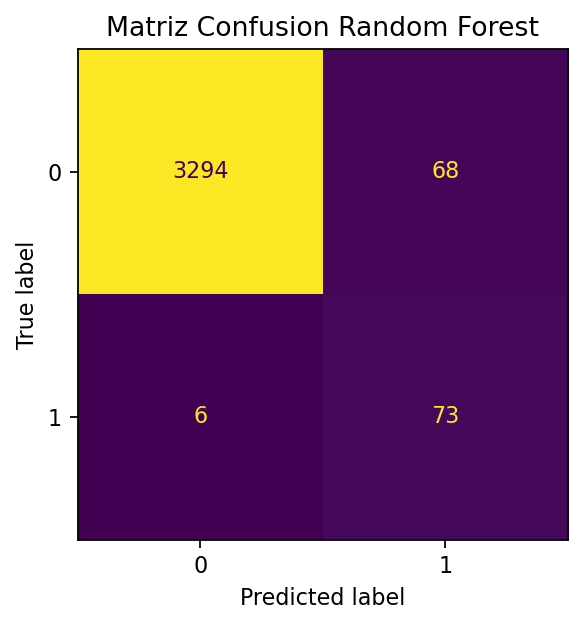

In [18]:
for fig in [cfg.FIG_CM_LOGISTIC, cfg.FIG_CM_RF]:
    if fig.exists():
        display(Image(filename=str(fig)))

In [19]:
model_results["confusion_matrices"]["logistica"]

,pred_0,pred_1
real_0,3239,123
real_1,5,74


In [20]:
model_results["confusion_matrices"]["random_forest"]

,pred_0,pred_1
real_0,3294,68
real_1,6,73


## 9. Despliegue técnico con Prefect, Docker, PostgreSQL/PostGIS y MongoDB

El proyecto incluye `docker-compose.yml` para levantar PostgreSQL/PostGIS y MongoDB. La orquestación está en `flows/pipeline.py`.

Para ejecutar el pipeline completo desde terminal:

```bash
python flows/pipeline.py
```

Para levantar bases de datos:

```bash
docker compose up -d postgres mongo
```

In [21]:
from bdtools.databases import load_databases

# Ejecutar esta celda solo después de levantar Docker.
# db_results = load_databases(df, gdf)
# db_results

## 10. Conclusiones técnicas

El proyecto queda organizado bajo CRISP-DM, con separación entre notebook, lógica reutilizable, orquestación y salidas. La solución genera archivos procesados, tablas de reporte, visualizaciones, GeoJSON y métricas de clasificación de manera reproducible.

Las salidas principales se almacenan en `data/processed`, `reports/tables` y `reports/figures`.

In [23]:
from pathlib import Path
import pandas as pd

outputs = [cfg.CLEAN_CSV, cfg.CLEAN_PARQUET, cfg.GEOJSON_FILE]
outputs += sorted(cfg.TABLES_DIR.glob("*.csv")) + sorted(cfg.TABLES_DIR.glob("*.json"))
outputs += sorted(cfg.FIGURES_DIR.glob("*.png"))

pd.DataFrame(
    [{"salida": str(p.relative_to(PROJECT_ROOT)), "existe": p.exists()} for p in outputs]
).drop_duplicates().sort_values("salida")

,salida,existe
0,data\processed\sievcac_limpio.csv,True
1,data\processed\sievcac_limpio.parquet,True
2,data\processed\sievcac_geo.geojson,True
3,reports\tables\calidad_datos.csv,True
4,reports\tables\resumen_general.csv,True
5,reports\tables\estadistica_descriptiva.csv,True
6,reports\tables\pruebas_chi_cuadrado.csv,True
7,reports\tables\model_metrics.csv,True
8,reports\tables\classification_report_logistica...,True
9,reports\tables\classification_report_random_fo...,True
